### Programming for Biomedical Informatics
#### Week 6 - Differential Gene Expression Analysis

This is a basic example of how to use pydeseq2 to perform differential expression analysis on a synthetic dataset that comes with the package. There is excellent documentation on the package website https://pydeseq2.readthedocs.io/en/latest/.

In [1]:
# import libraries
import os
import pickle as pkl

# import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import *

In [ ]:
import pandas as pd

# import small synthetic dataset
DATA_PATH = "https://raw.githubusercontent.com/owkin/PyDESeq2/main/datasets/synthetic/"

## NB this is only for 10 genes!
counts_df = pd.read_csv(os.path.join(DATA_PATH, "test_counts.csv"), index_col=0)
counts_df.head(10)

## These are RNA sequences integer
# How many times have I mapped short read to a part of the genome that maps to a particular gene - see slide on exons and 
# introns with alignment over the exon bits e.g. these bits are expressed
# There are no comments on transcripts e.g. alternate transcripts, you can summarise at many different levels, this summarises on the gene level



,sample1,sample2,sample3,sample4,sample5,sample6,sample7,sample8,sample9,sample10,...,sample91,sample92,sample93,sample94,sample95,sample96,sample97,sample98,sample99,sample100
gene1,12,1,4,1,1,0,0,2,5,18,...,0,9,5,27,2,7,1,10,18,21
gene2,21,44,4,10,11,8,14,19,19,11,...,31,43,13,12,24,26,14,36,14,9
gene3,4,2,11,2,6,2,17,11,9,8,...,11,4,12,0,1,3,3,2,3,3
gene4,130,63,180,100,135,36,159,60,66,157,...,119,86,112,89,73,67,71,72,66,42
gene5,18,11,21,44,16,26,11,19,7,35,...,50,41,21,86,31,11,33,11,53,13
gene6,0,10,3,9,2,3,19,2,3,0,...,10,0,3,0,12,4,5,2,11,13
gene7,16,70,28,28,32,36,39,41,13,31,...,4,20,31,18,27,41,19,66,32,19
gene8,54,32,34,16,29,42,22,83,25,52,...,28,32,22,39,33,44,42,27,19,78
gene9,49,57,65,33,31,42,38,46,52,37,...,15,45,24,72,67,54,25,16,79,30
gene10,3,9,2,9,5,17,6,12,3,10,...,13,1,31,28,4,1,4,9,11,5


In [ ]:
# transpose the counts matrix so that we have sample as rows and genes as columns
# NB this is a bit of an idiosynchoracy of the way PyDESeq2 has been implemented the original R implementation DESeq2 takes a gene x sample matrix rather than a sample x gene one!
counts_df = counts_df.T
counts_df.head()

## It wants the samples as rows and genes as columns
## May be due to the way it's indexed

,gene1,gene2,gene3,gene4,gene5,gene6,gene7,gene8,gene9,gene10
sample1,12,21,4,130,18,0,16,54,49,3
sample2,1,44,2,63,11,10,70,32,57,9
sample3,4,4,11,180,21,3,28,34,65,2
sample4,1,10,2,100,44,9,28,16,33,9
sample5,1,11,6,135,16,2,32,29,31,5


In [ ]:
## load the meta-data
metadata = pd.read_csv(os.path.join(DATA_PATH, "test_metadata.csv"), index_col=0)
metadata.head()

## Provided a two factor meta data information, there are two conditions present in thei dataset e.g. A is disease, B healtha, male female etc.
## There can be many confounding factors that you many want to account for using multifactor analysis

,condition,group
sample1,A,X
sample2,A,Y
sample3,A,X
sample4,A,Y
sample5,A,X


In [6]:
## filter out samples with missing condition
samples_to_keep = ~metadata.condition.isna()
counts_df = counts_df.loc[samples_to_keep]
metadata = metadata.loc[samples_to_keep]

In [ ]:
counts_df.sum(axis=0) >= 10 ## Just genes that don't show up more than 10 times

gene1     True
gene2     True
gene3     True
gene4     True
gene5     True
gene6     True
gene7     True
gene8     True
gene9     True
gene10    True
dtype: bool

In [11]:
## remove the genes with low counts
# Anys sam -> literature talks about how many to remove
genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= 10]
counts_df = counts_df[genes_to_keep]

In [14]:
## set up the DESeq2 object
inference = DefaultInference(n_cpus=8)
dds = DeseqDataSet(
    counts=counts_df,
    metadata=metadata,
    design="condition",
    refit_cooks=True,
    inference=inference,
)

## Does some outlier detection uses a cooks statistic

In [ ]:
## do the fitting - this does it all in one go, we break it down in the next notebook
dds.deseq2()

### Size factors - we need to scale by how well experiments go, so that there are not twice as many reads
## Remember that one of the technical issues, very lowly expressed genes are more variant, this is not heteroskodastic
### It makes a posthoc bayesian transformation of the estimation

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.04 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.02 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [ ]:
## look at the results
print(dds) ### Mimics the way R does it.

# There are lots of slots of information
# Gene wise dispersions and fitted dispersions are of interest
# Ultimately, the gene wise dispersions are *observed data*
# Fit is how well the model we created to correct it works
# We hope there should be a linear one to one relationship with them

AnnData object with n_obs × n_vars = 100 × 10
    obs: 'condition', 'group', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'


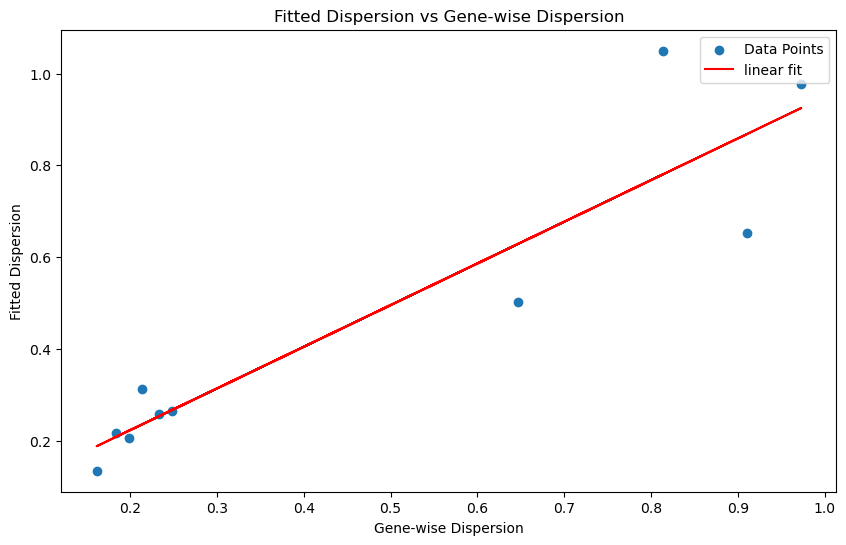

In [ ]:
## access the dispersion estimates
genewise_dispersions = dds.var["genewise_dispersions"]
fitted_dispersions = dds.var['fitted_dispersions']

# plot genewise vs fitted dispersions
plt.figure(figsize=(10,6))
plt.scatter(genewise_dispersions, fitted_dispersions, label='Data Points')

# calculate the linear trend line
m, b = np.polyfit(genewise_dispersions, fitted_dispersions, 1)  # 1 for linear
plt.plot(genewise_dispersions, m * genewise_dispersions + b, color='red', label='linear fit')

plt.xlabel('Gene-wise Dispersion')
plt.ylabel('Fitted Dispersion')
plt.title('Fitted Dispersion vs Gene-wise Dispersion')
plt.legend()
plt.show()


### 
# Allthough we have ten genes, these are broadly linear, with a cloud along teh diagonal
## there may be a few unusual genes that we want to look like if it's an actual outlier to remove or not



In [ ]:
## access the log2 fold changes, typically log 2 scale e.g. an increase in 1 is a square increase
print(dds.varm["LFC"])

        Intercept  condition[T.B]
gene1    1.891436        0.438632
gene2    2.851662        0.373296
gene3    1.787780       -0.438645
gene4    4.741958       -0.285647
gene5    3.077798        0.403457
gene6    1.678536        0.001010
gene7    3.291025        0.093116
gene8    3.785129       -0.187604
gene9    3.682882       -0.147443
gene10   2.300515        0.267562


In [ ]:
## now we can calculate the statistics
stat_res = DeseqStats(dds, contrast=['condition','A','B'], inference=inference)
stat_res.summary()

## We get a base mean, estimate, a t test statistic, the p value and the adjusted p value
# Controlling the error is of greate importance

Log2 fold change & Wald test p-value: condition A vs B
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene1     8.541317       -0.632812  0.289101 -2.188898  0.028604  0.064150
gene2    21.281239       -0.538552  0.149963 -3.591236  0.000329  0.001646
gene3     5.010123        0.632830  0.295236  2.143476  0.032075  0.064150
gene4   100.517961        0.412102  0.118629  3.473868  0.000513  0.001710
gene5    27.142450       -0.582065  0.154706 -3.762409  0.000168  0.001646
gene6     5.413043       -0.001457  0.310311 -0.004696  0.996253  0.996253
gene7    28.294023       -0.134338  0.149945 -0.895917  0.370297  0.411441
gene8    40.358344        0.270656  0.136401  1.984261  0.047227  0.078711
gene9    37.166183        0.212715  0.133243  1.596437  0.110391  0.143147
gene10   11.589325       -0.386011  0.244588 -1.578207  0.114518  0.143147


Running Wald tests...
... done in 0.07 seconds.



Running Wald tests...
... done in 3.05 seconds.



Log2 fold change & Wald test p-value: condition A vs B
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene1     8.541317       -0.632812  0.289101 -1.842998  0.065329  0.142223
gene2    21.281239       -0.538552  0.149963 -2.924404  0.003451  0.017256
gene3     5.010123        0.632830  0.295236  1.804763  0.071112  0.142223
gene4   100.517961        0.412102  0.118629  2.630904  0.008516  0.028386
gene5    27.142450       -0.582065  0.154706 -3.116020  0.001833  0.017256
gene6     5.413043       -0.001457  0.310311  0.000000  1.000000  1.000000
gene7    28.294023       -0.134338  0.149945 -0.229004  0.818866  0.909851
gene8    40.358344        0.270656  0.136401  1.251130  0.210887  0.346086
gene9    37.166183        0.212715  0.133243  0.845931  0.397591  0.496989
gene10   11.589325       -0.386011  0.244588 -1.169357  0.242260  0.346086


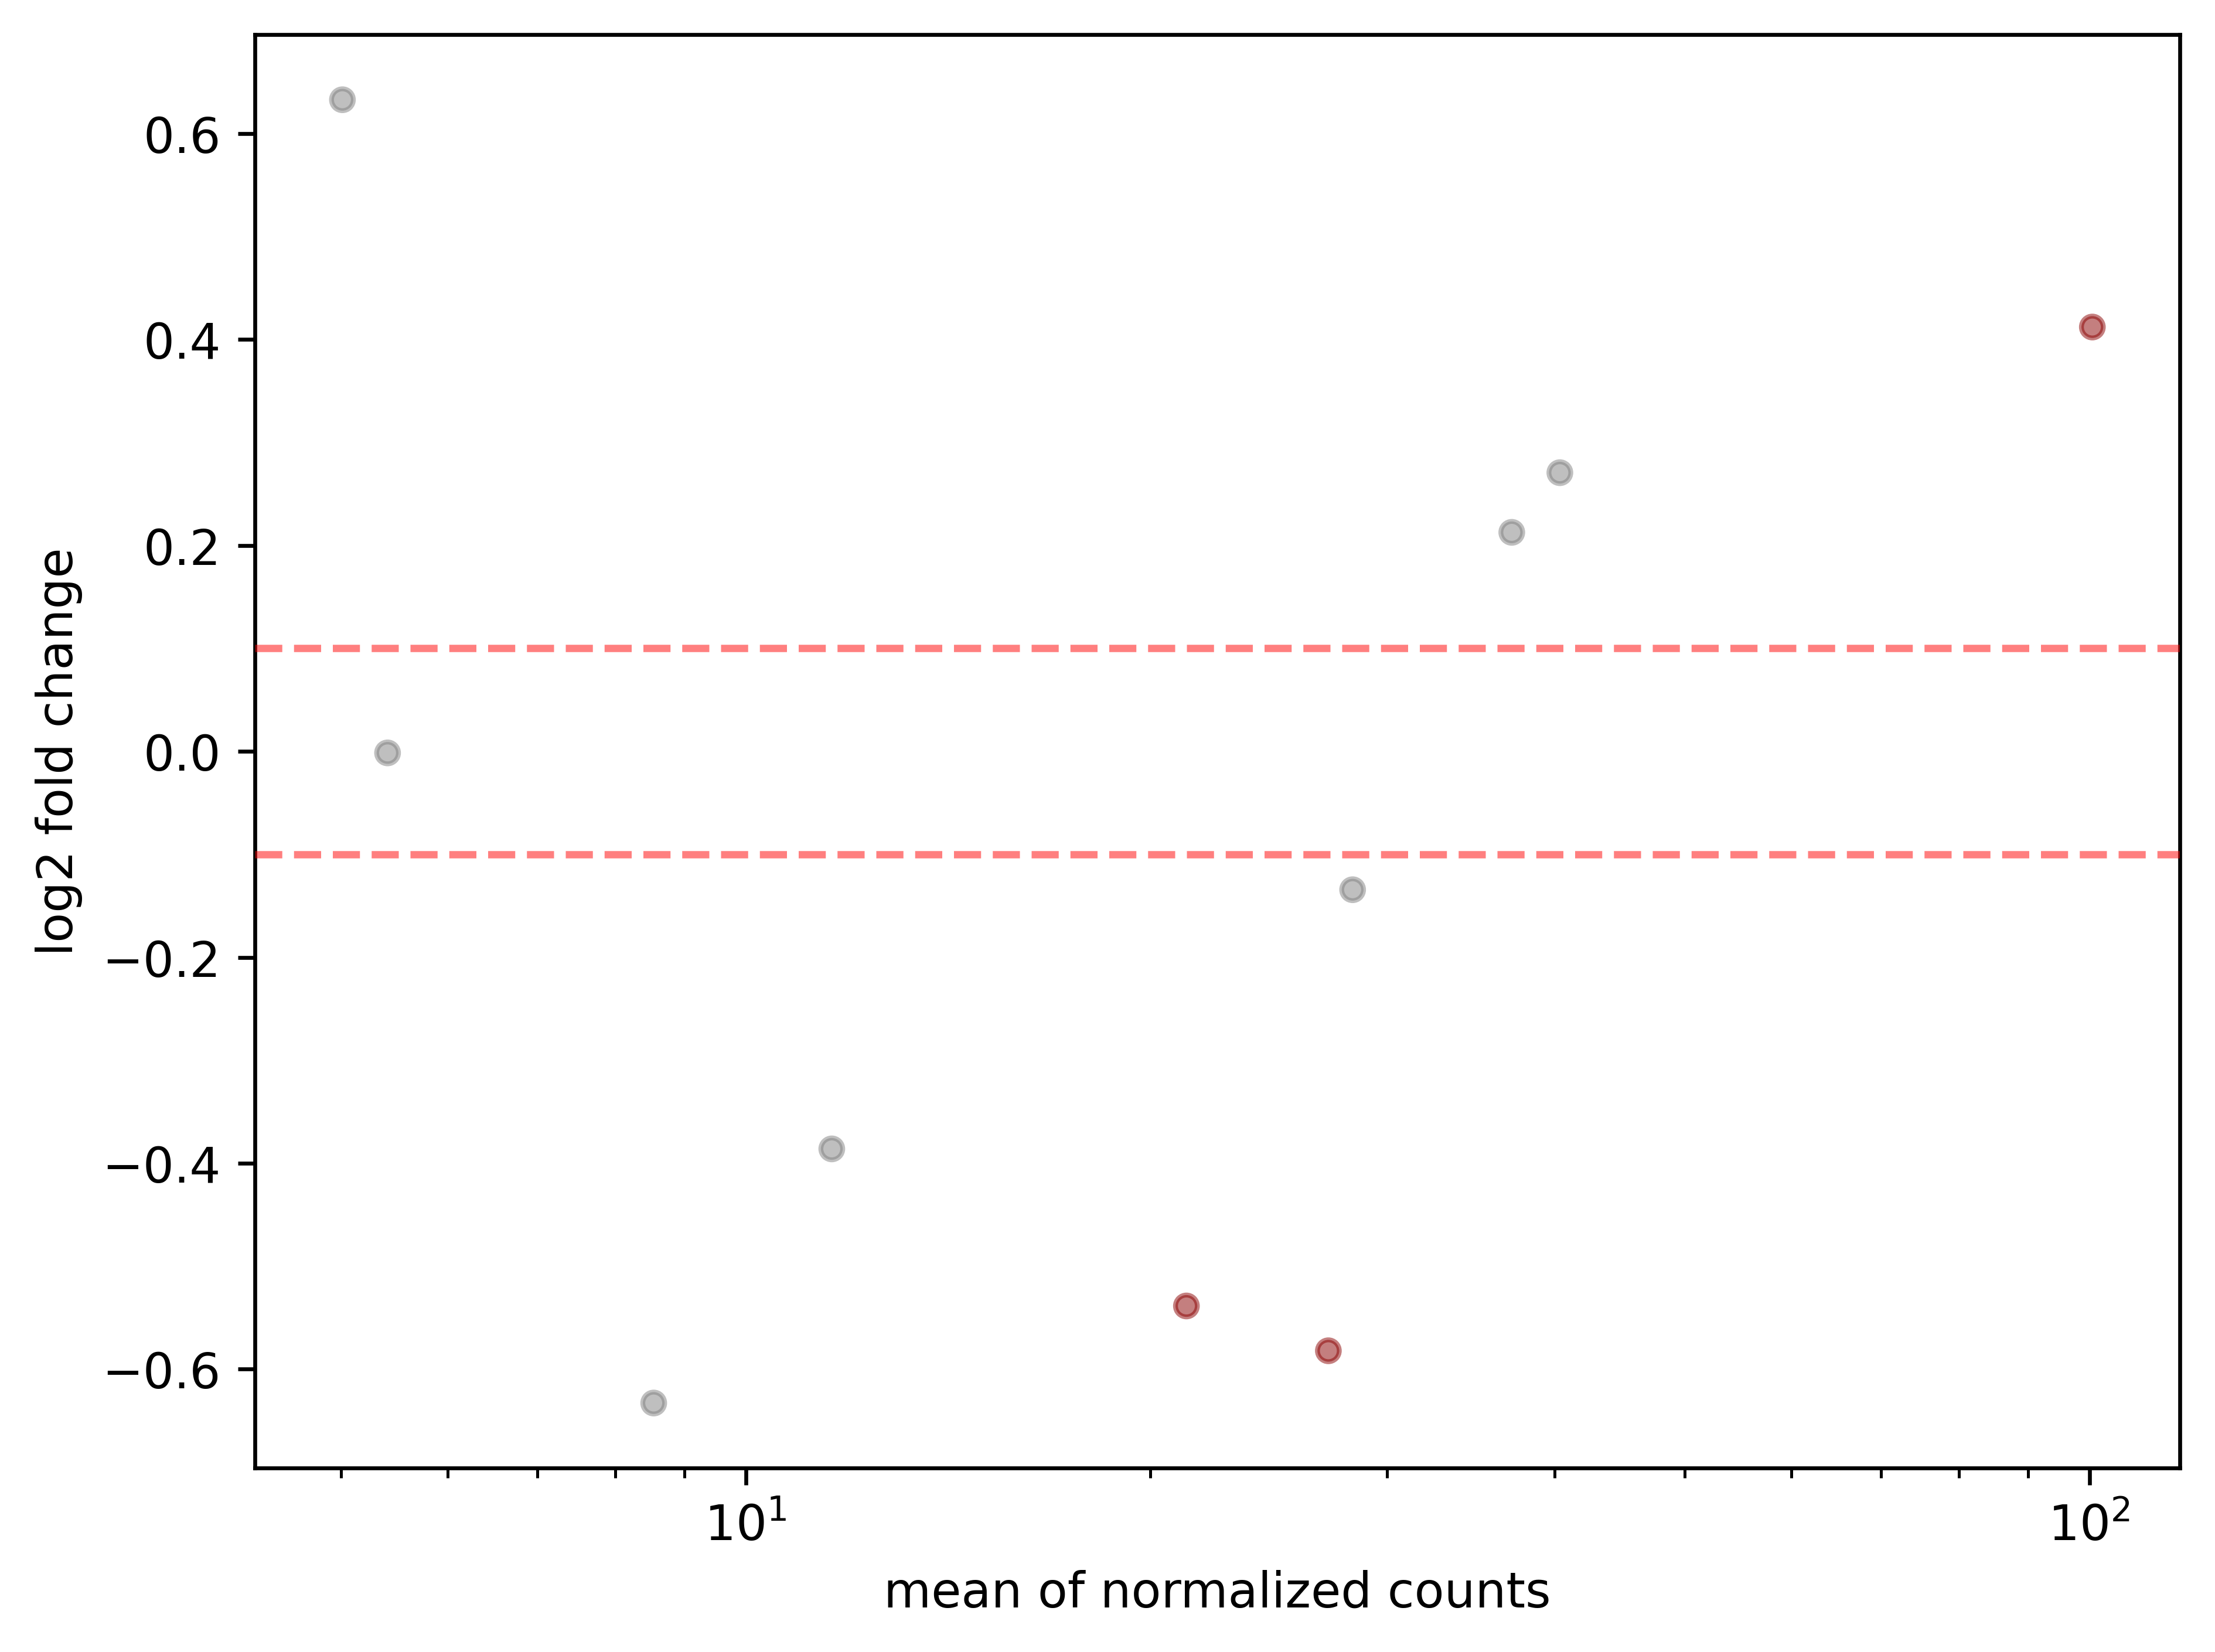

In [ ]:
## plot an MA plot of the results
## remember only 10 genes!
stat_res.summary(lfc_null=0.1, alt_hypothesis="greaterAbs")
stat_res.plot_MA(s=20)

## Ones that are red are statistically significant.
# It is very commonly the case that equivalent log2foldchange values have similar values
# But depending on the variation of the gene, even small log2foldchanges can be statistically significant

## A small change in a master regulator can change can have huge significance!!